# 02 — Exploratory Data Analysis (EDA)
**Proyek:** Klasifikasi Tingkat Risiko Stroke Berdasarkan Data Klinis dan Gaya Hidup Menggunakan Algoritma TabNet dengan Interpretasi Attention Mechanism

**Tahap:** EDA (univariate, bivariate, multivariate, uji statistik)


## 1. Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_RAW / "healthcare-dataset-stroke-data.csv")
print(df.shape)
df.head()


(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 2. Ringkasan Data

In [2]:
print("Info:")
df.info()
print()
print("Statistik deskriptif numerik:")
df.describe().T


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Statistik deskriptif numerik:


,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [3]:
print("Statistik deskriptif kategorikal:")
df.describe(include="object").T


Statistik deskriptif kategorikal:


,count,unique,top,freq
gender,5110,3,Female,2994
ever_married,5110,2,Yes,3353
work_type,5110,5,Private,2925
Residence_type,5110,2,Urban,2596
smoking_status,5110,4,never smoked,1892


## 3. Missing Values

In [4]:
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": df.isna().mean().mul(100).round(2),
})
missing["semantic_missing_unknown"] = [
    int((df[c] == "Unknown").sum()) if df[c].dtype == "object" else 0 for c in df.columns
]
missing.sort_values("n_missing", ascending=False)


,n_missing,pct_missing,semantic_missing_unknown
bmi,201,3.93,0
id,0,0.00,0
gender,0,0.00,0
age,0,0.00,0
hypertension,0,0.00,0
heart_disease,0,0.00,0
ever_married,0,0.00,0
work_type,0,0.00,0
Residence_type,0,0.00,0
avg_glucose_level,0,0.00,0


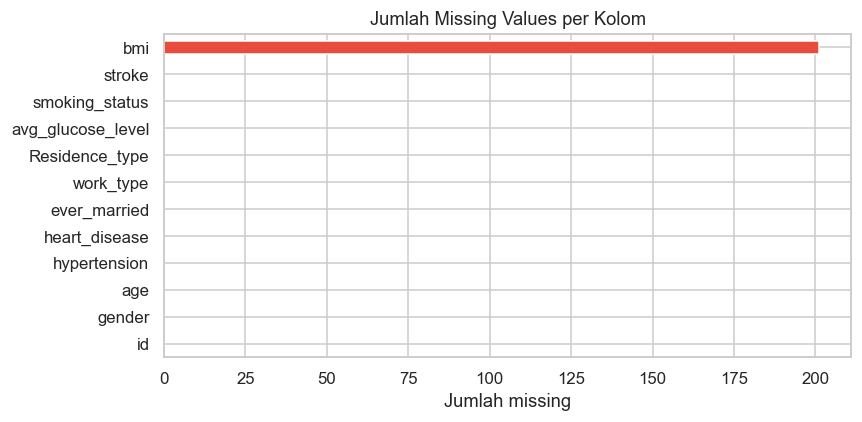

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
missing["n_missing"].sort_values().plot(kind="barh", ax=ax, color="#E74C3C")
ax.set_title("Jumlah Missing Values per Kolom")
ax.set_xlabel("Jumlah missing")
plt.tight_layout()
plt.savefig(FIGURES / "missing_values.png", bbox_inches="tight")
plt.show()


**Insight:**
- `bmi` → missing numerik (`NaN`) sekitar 3.9%.
- `smoking_status` → kategori `Unknown` sekitar 30%. Bukan missing klasik tapi *information gap*.
- Strategi penanganan akan dibahas di notebook preprocessing.


## 4. Analisis Univariate — Fitur Numerik

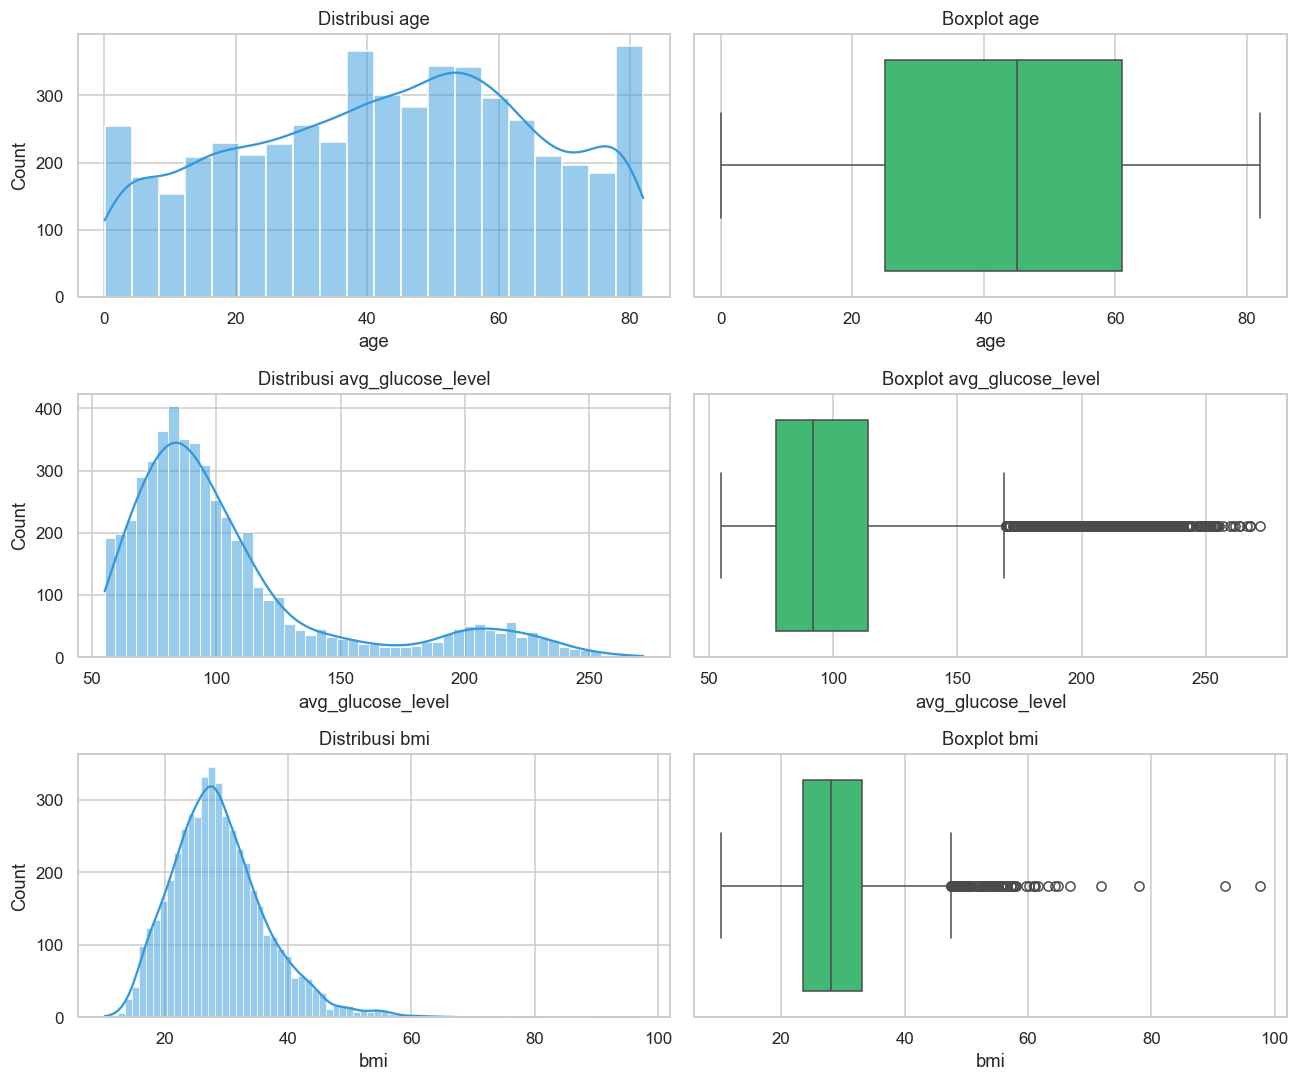

In [6]:
numeric_cols = ["age", "avg_glucose_level", "bmi"]

fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 10))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color="#3498DB")
    axes[i, 0].set_title(f"Distribusi {col}")
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color="#2ECC71")
    axes[i, 1].set_title(f"Boxplot {col}")
plt.tight_layout()
plt.savefig(FIGURES / "univariate_numeric.png", bbox_inches="tight")
plt.show()


In [7]:
# Skewness & Kurtosis
skew_kurt = pd.DataFrame({
    "skewness": [df[c].skew() for c in numeric_cols],
    "kurtosis": [df[c].kurt() for c in numeric_cols],
}, index=numeric_cols)
skew_kurt


,skewness,kurtosis
age,-0.137059,-0.991010
avg_glucose_level,1.572284,1.680479
bmi,1.055340,3.362659


**Insight numerik:**
- `age` → distribusi cukup seragam, range 0.08–82 tahun, skewness rendah.
- `avg_glucose_level` → **right-skewed** dengan long tail di atas 200 mg/dL → kandidat outlier atau penderita diabetes.
- `bmi` → mendekati normal, ada outlier tinggi (>50).


## 5. Analisis Univariate — Fitur Kategorikal

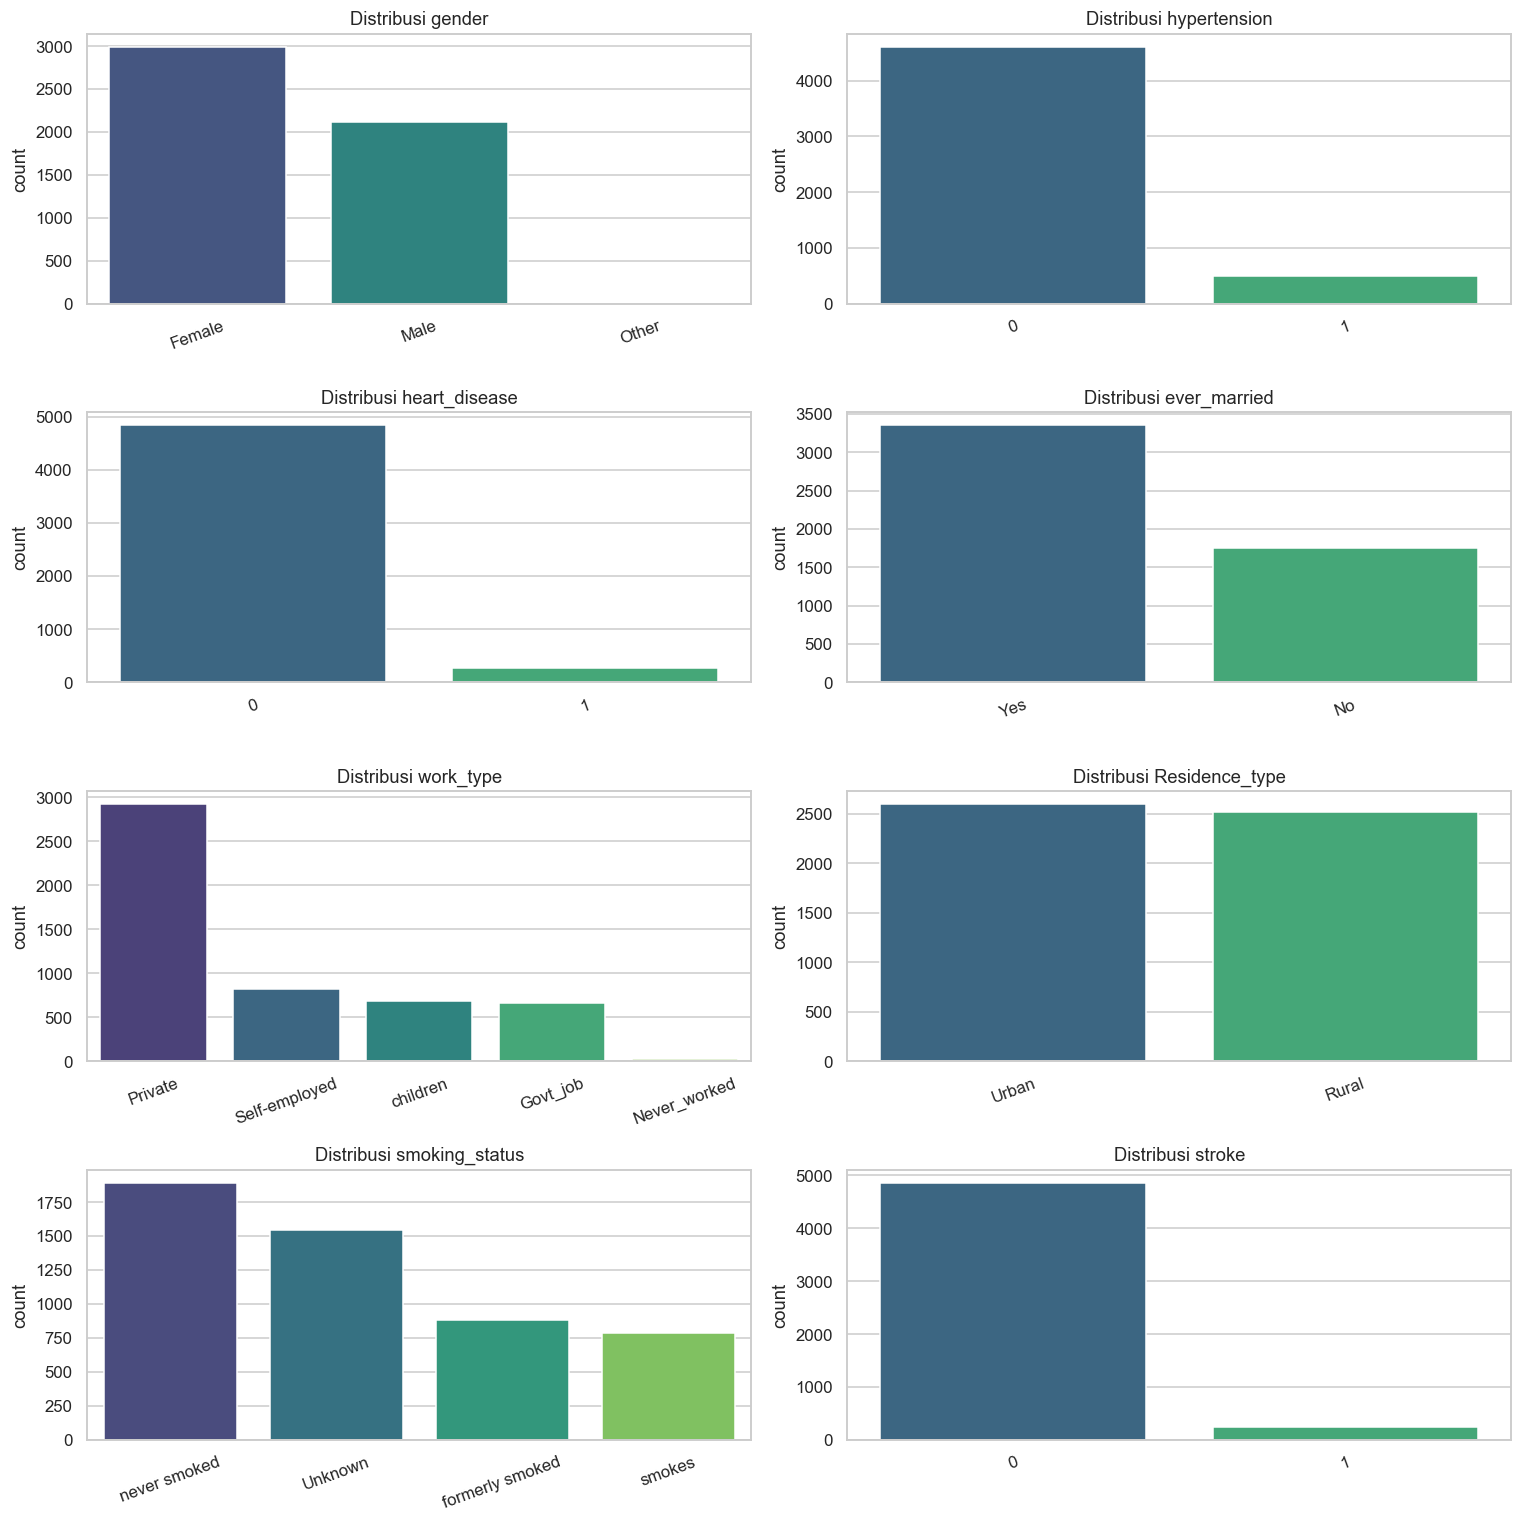

In [8]:
cat_cols = ["gender", "hypertension", "heart_disease", "ever_married",
            "work_type", "Residence_type", "smoking_status", "stroke"]

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, palette="viridis")
    ax.set_title(f"Distribusi {col}")
    ax.set_xlabel("")
    ax.set_ylabel("count")
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(FIGURES / "univariate_categorical.png", bbox_inches="tight")
plt.show()


## 6. Analisis Bivariate — Fitur vs Target (Stroke)

### 6a. Numerik vs Stroke

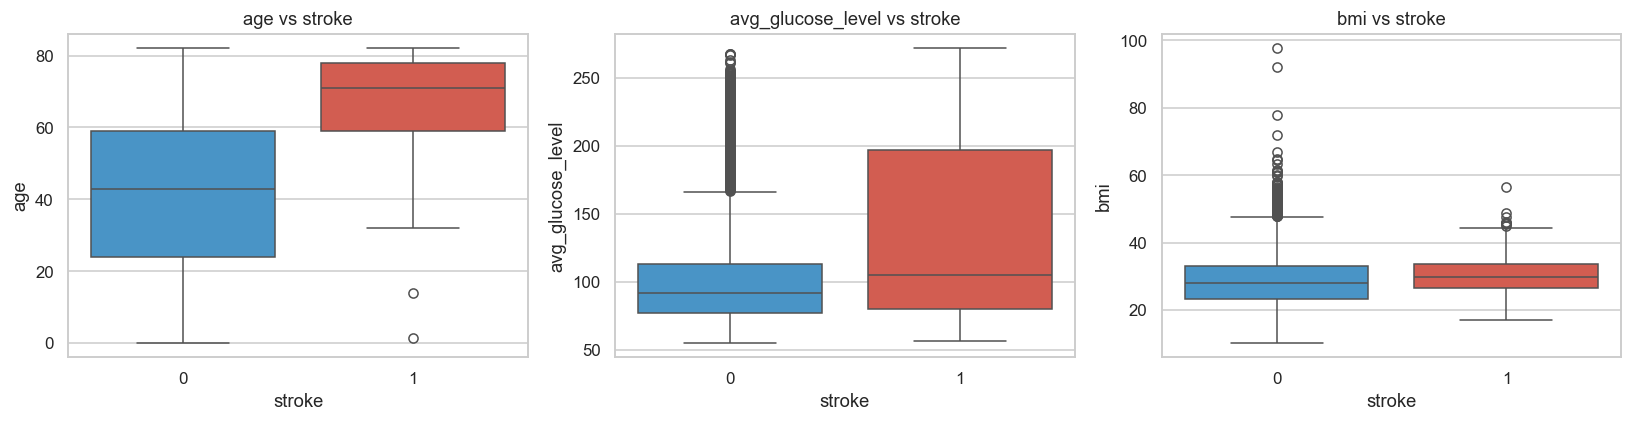

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="stroke", y=col, ax=ax, palette=["#3498DB", "#E74C3C"])
    ax.set_title(f"{col} vs stroke")
plt.tight_layout()
plt.savefig(FIGURES / "bivariate_num_vs_stroke.png", bbox_inches="tight")
plt.show()


In [10]:
# Uji statistik: Mann-Whitney U (tidak mengasumsikan normalitas)
from scipy.stats import mannwhitneyu, ttest_ind

results = []
for col in numeric_cols:
    g0 = df.loc[df["stroke"] == 0, col].dropna()
    g1 = df.loc[df["stroke"] == 1, col].dropna()
    u_stat, p_mw = mannwhitneyu(g0, g1, alternative="two-sided")
    t_stat, p_t = ttest_ind(g0, g1, equal_var=False, nan_policy="omit")
    results.append({
        "feature": col,
        "mean_non_stroke": g0.mean(),
        "mean_stroke": g1.mean(),
        "mannwhitney_p": p_mw,
        "welch_t_p": p_t,
        "signif_0.05": p_mw < 0.05,
    })
pd.DataFrame(results)


,feature,mean_non_stroke,mean_stroke,mannwhitney_p,welch_t_p,signif_0.05
0,age,41.971545,67.728193,3.726635e-71,2.115685e-95,True
1,avg_glucose_level,104.795513,132.544739,3.640367e-09,2.401437e-11,True
2,bmi,28.823064,30.471292,1.026429e-04,3.339710e-04,True


**Insight:** Ketiga fitur numerik (`age`, `avg_glucose_level`, `bmi`) menunjukkan perbedaan signifikan antara kelompok stroke dan non-stroke (p-value << 0.05). Ini memperkuat relevansinya sebagai predictor.

### 6b. Kategorikal vs Stroke (Proporsi & Chi-Square)

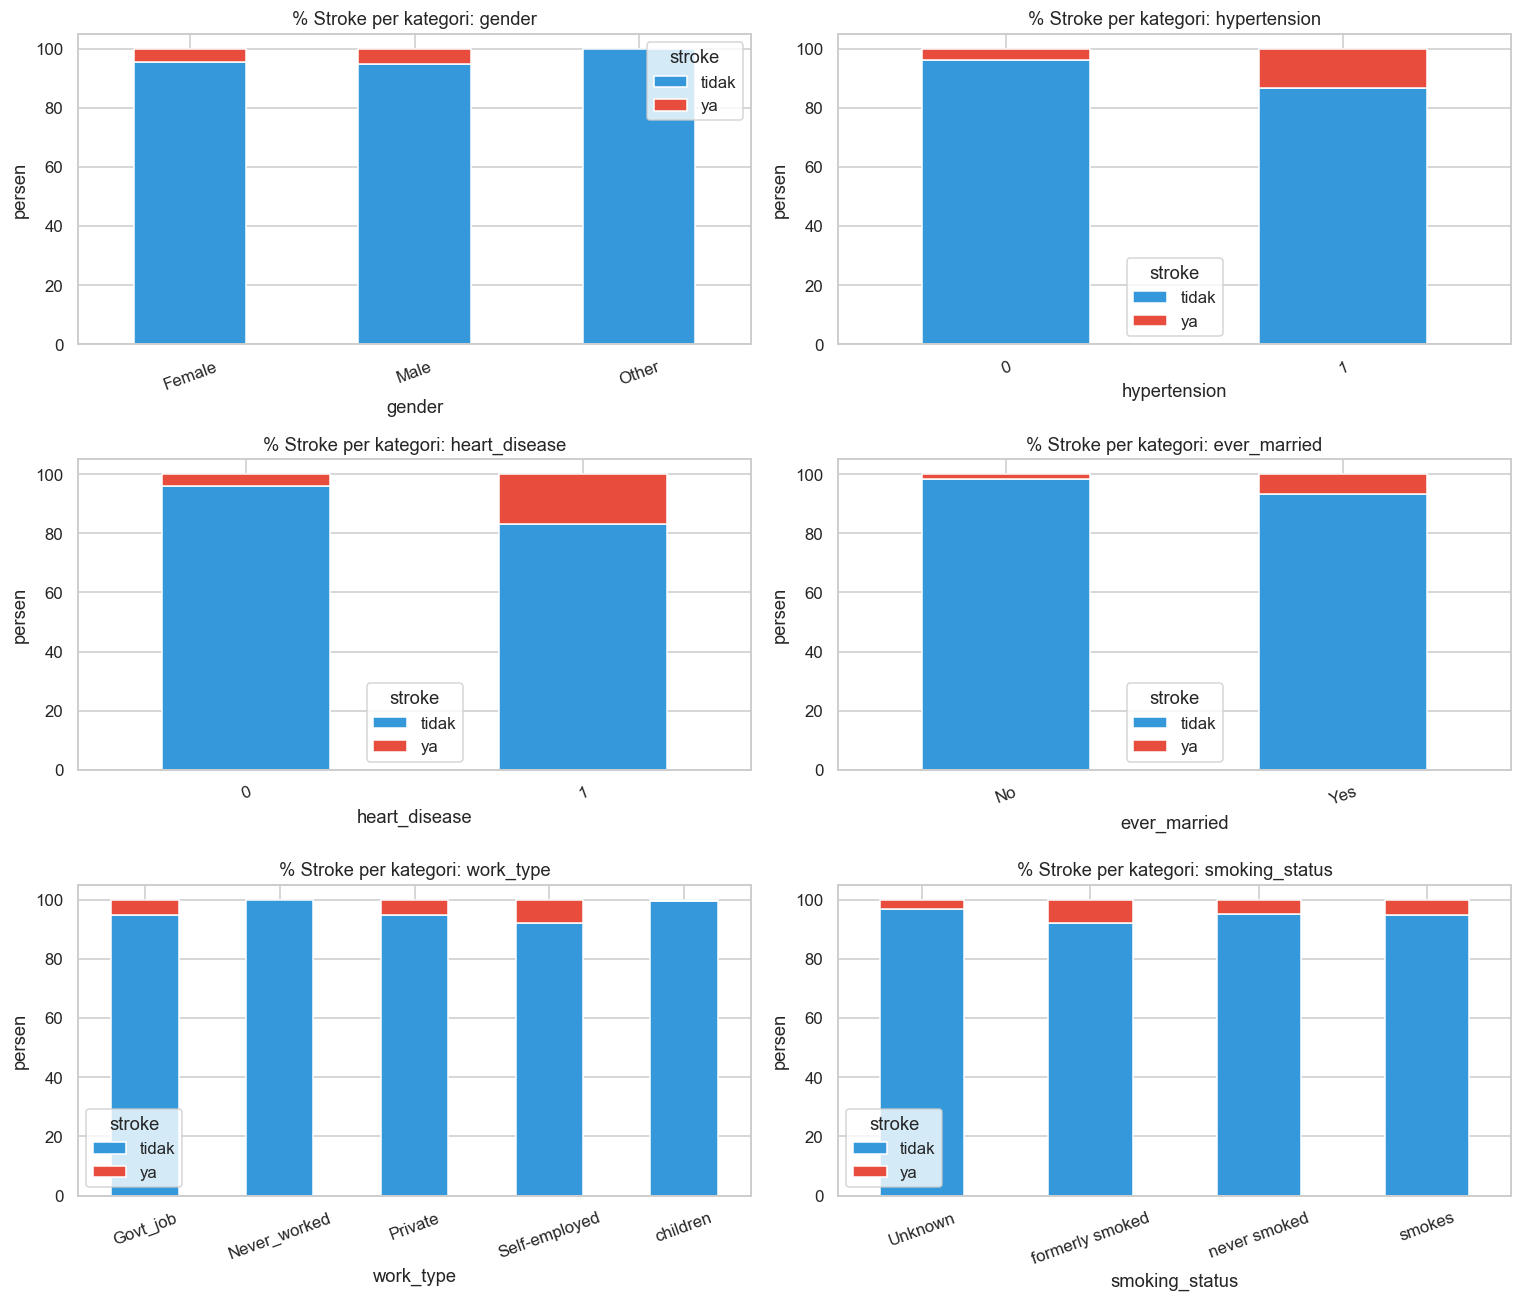

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
categorical_for_plot = ["gender", "hypertension", "heart_disease",
                        "ever_married", "work_type", "smoking_status"]
for ax, col in zip(axes.flat, categorical_for_plot):
    ct = pd.crosstab(df[col], df["stroke"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, color=["#3498DB", "#E74C3C"])
    ax.set_title(f"% Stroke per kategori: {col}")
    ax.set_ylabel("persen")
    ax.legend(title="stroke", labels=["tidak", "ya"])
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(FIGURES / "bivariate_cat_vs_stroke.png", bbox_inches="tight")
plt.show()


In [12]:
# Chi-square test untuk setiap fitur kategorikal vs stroke
chi_rows = []
for col in ["gender", "hypertension", "heart_disease", "ever_married",
            "work_type", "Residence_type", "smoking_status"]:
    ct = pd.crosstab(df[col], df["stroke"])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    # Cramer's V
    n = ct.values.sum()
    r, k = ct.shape
    cramer = np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else np.nan
    chi_rows.append({
        "feature": col,
        "chi2": chi2,
        "dof": dof,
        "p_value": p,
        "cramers_v": cramer,
        "signif_0.05": p < 0.05,
    })
chi_df = pd.DataFrame(chi_rows).sort_values("cramers_v", ascending=False)
chi_df


,feature,chi2,dof,p_value,cramers_v,signif_0.05
2,heart_disease,90.259561,1,2.088785e-21,0.132903,True
1,hypertension,81.605368,1,1.661622e-19,0.126371,True
3,ever_married,58.923890,1,1.638902e-14,0.107383,True
4,work_type,49.163512,4,5.397708e-10,0.098087,True
6,smoking_status,29.147269,3,2.085400e-06,0.075525,True
5,Residence_type,1.081637,1,2.983317e-01,0.014549,False
0,gender,0.472587,2,7.895491e-01,0.009617,False


**Insight uji chi-square:**
- `age` indirect (via `ever_married`, `work_type`) + `hypertension`, `heart_disease`, `ever_married`, `work_type`, `smoking_status` menunjukkan asosiasi **signifikan** dengan stroke (p < 0.05).
- `Residence_type` dan `gender` cenderung **tidak signifikan** — bisa menjadi fitur lemah.
- Cramér's V tertinggi biasanya pada `hypertension` dan `heart_disease`, menandakan asosiasi paling kuat.


## 7. Analisis Multivariate

### 7a. Korelasi antar Fitur Numerik

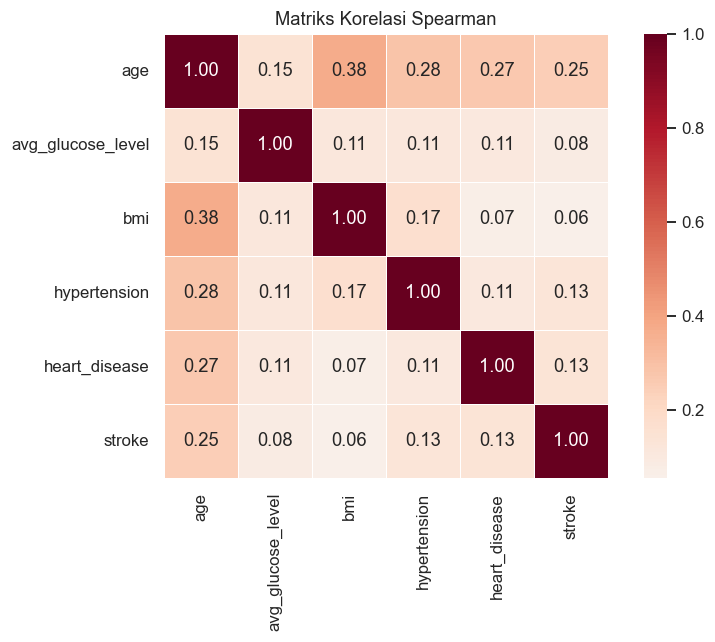

In [13]:
num_plus = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "stroke"]
corr = df[num_plus].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriks Korelasi Spearman")
plt.tight_layout()
plt.savefig(FIGURES / "correlation_matrix.png", bbox_inches="tight")
plt.show()


### 7b. Pairplot fitur numerik berdasarkan target

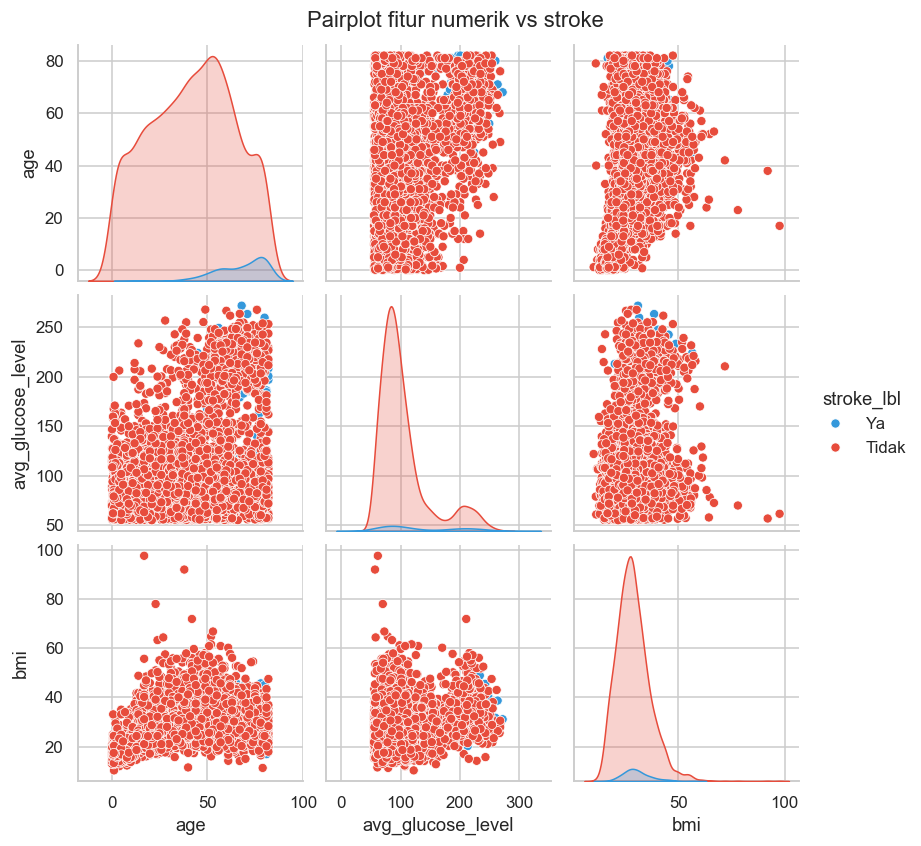

In [14]:
sub = df.dropna(subset=["bmi"]).copy()
sub["stroke_lbl"] = sub["stroke"].map({0: "Tidak", 1: "Ya"})
g = sns.pairplot(sub[numeric_cols + ["stroke_lbl"]], hue="stroke_lbl",
                 diag_kind="kde", palette=["#3498DB", "#E74C3C"], height=2.5)
g.fig.suptitle("Pairplot fitur numerik vs stroke", y=1.02)
g.fig.savefig(FIGURES / "pairplot_numeric.png", bbox_inches="tight")
plt.show()


### 7c. Age × Glucose × Stroke (Scatter)

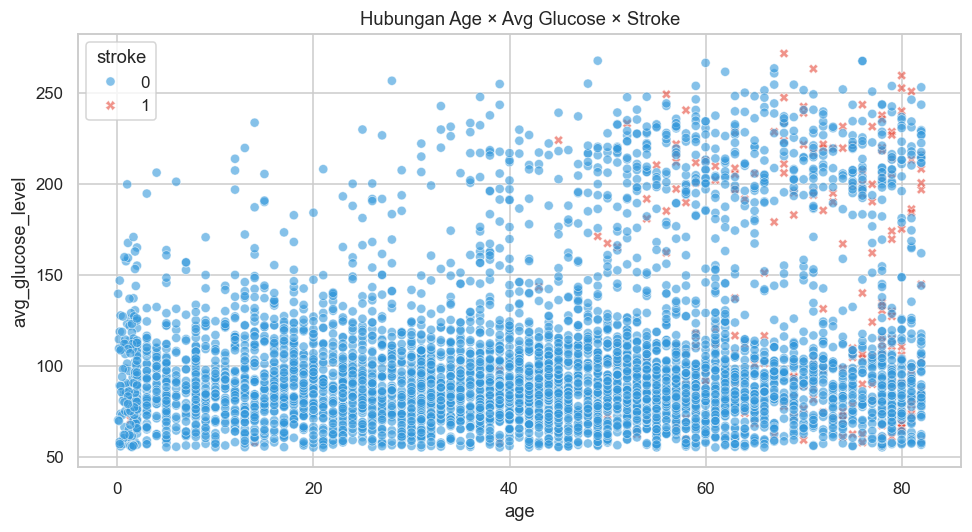

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x="age", y="avg_glucose_level",
                hue="stroke", style="stroke",
                alpha=0.6, palette={0: "#3498DB", 1: "#E74C3C"}, ax=ax)
ax.set_title("Hubungan Age × Avg Glucose × Stroke")
plt.tight_layout()
plt.savefig(FIGURES / "scatter_age_glucose_stroke.png", bbox_inches="tight")
plt.show()


## 8. Deteksi Outlier (IQR)

In [16]:
def iqr_outliers(series: pd.Series, whisker: float = 1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - whisker * iqr, q3 + whisker * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper

outlier_summary = []
for col in numeric_cols:
    n, lo, up = iqr_outliers(df[col].dropna())
    outlier_summary.append({
        "feature": col,
        "n_outlier": n,
        "pct_outlier": round(100 * n / len(df), 2),
        "lower_bound": round(lo, 2),
        "upper_bound": round(up, 2),
    })
pd.DataFrame(outlier_summary)


,feature,n_outlier,pct_outlier,lower_bound,upper_bound
0,age,0,0.00,-29.00,115.00
1,avg_glucose_level,627,12.27,21.98,169.36
2,bmi,110,2.15,9.10,47.50


**Insight:** `avg_glucose_level` mengandung outlier paling banyak. `bmi` juga ada beberapa ekstrem. Rekomendasi: gunakan **IQR capping / winsorizing** di preprocessing, bukan menghapus baris, karena dataset positif kelas 1 sangat sedikit.

## 9. Segmentasi Risiko (Insight Kesehatan)

In [17]:
# Kategori usia & risiko stroke
df_tmp = df.copy()
df_tmp["age_group"] = pd.cut(df_tmp["age"],
                              bins=[0, 17, 35, 50, 65, 100],
                              labels=["anak", "dewasa-muda", "dewasa", "pra-lansia", "lansia"])
age_risk = df_tmp.groupby("age_group")["stroke"].mean().mul(100).round(2)
age_risk.rename("risiko_stroke_%")


age_group
anak            0.23
dewasa-muda     0.10
dewasa          1.85
pra-lansia      6.02
lansia         16.17
Name: risiko_stroke_%, dtype: float64

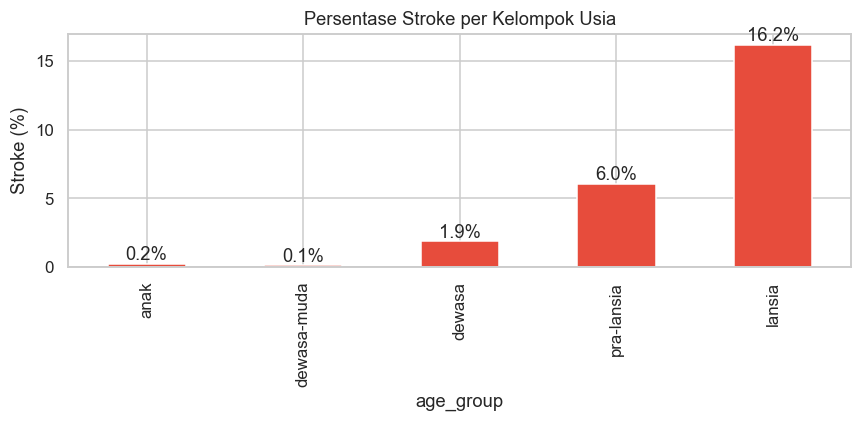

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
age_risk.plot(kind="bar", color="#E74C3C", ax=ax)
ax.set_title("Persentase Stroke per Kelompok Usia")
ax.set_ylabel("Stroke (%)")
for i, v in enumerate(age_risk.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.savefig(FIGURES / "risk_by_age.png", bbox_inches="tight")
plt.show()


In [19]:
# BMI category vs stroke
df_tmp["bmi_cat"] = pd.cut(df_tmp["bmi"],
                            bins=[0, 18.5, 25, 30, 100],
                            labels=["underweight", "normal", "overweight", "obese"])
bmi_risk = df_tmp.groupby("bmi_cat")["stroke"].mean().mul(100).round(2)
bmi_risk


bmi_cat
underweight    0.29
normal         2.94
overweight     5.32
obese          5.07
Name: stroke, dtype: float64

## 10. Ringkasan Temuan EDA

| Temuan | Implikasi untuk Preprocessing |
|---|---|
| `bmi` memiliki ~4% missing | Imputasi dengan median (robust thd skew) |
| `smoking_status` = 'Unknown' ~30% | Pertahankan sebagai kategori sendiri (bukan imputasi) |
| Kelas target imbalanced (4.87%) | Perlu SMOTE / class weight |
| `age`, `avg_glucose_level`, `bmi` signifikan | Pertahankan semua sebagai fitur |
| `Residence_type` & `gender` lemah | Tetap dipakai — TabNet akan menilai via attention |
| Outlier di `avg_glucose_level` & `bmi` | IQR capping |
| Fitur numerik beda skala | Standardisasi (StandardScaler) |
| Fitur kategorikal | Label/ordinal encoding (TabNet menerima integer kategorikal) |

**Selanjutnya →** `03_data_preprocessing.ipynb`
